# Binary roundtrip: what survives the grid?

**Workflow 4 — analyse representations.** Explore notes → binary occupancy →
reconstructed notes, then follow original cells back to the score.

A binary cell answers **“is this pitch sounding during this time step?”**
It does not encode how many voices sound that pitch, where touching repeated
notes begin, or how a note was written. The notebook measures these losses.

1. A nine-note example makes resolution, pitch axes, repetition and overlap visible.
2. A real score puts the same checks beside its source provenance.
3. A selected score fragment becomes a kernel; its search result is traced back to source notes.
4. An optional extension edits the toy grid, generates new music and searches with the edited query.

Run all cells in order. Toy experiments and editing work offline. The real-score
section uses cached Bach *Ein feste Burg*, falling back to a bundled MEI when
Bach is not cached. Set the source and display controls in section 5.

Two worked searches follow **kernel → heatmap → binary window → highlighted source notation**, including a match that disappears when voices are searched independently.


In [1]:
try:
    import camat
except ModuleNotFoundError:
    import setup_camat
    import camat

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from camat import (
    extract_selected_xml_ids, find_camat_root, parse_files, resolve_mei_source,
    vrv_load_from_file, vrv_quiet, vrv_set_options,
)
from camat.verovio_render import vrv_render_source_context, vrv_render_all_pages, vrv_display_svg
from camat.music_utils import (
    binary_matrix_to_df_from_meta, create_binary_matrix_bundle, draw_piano_roll,
    get_binary_cell_provenance, get_binary_window_provenance,
)
from camat.binary_roundtrip import (
    audit_binary_roundtrip, compare_binary_resolutions, compare_voice_roundtrips,
    describe_binary_span_sources, make_roundtrip_example,
    plot_binary_comparison, plot_note_comparison, prepare_binary_timeline,
    split_binary_voices, find_binary_matches, binary_match_sources, plot_binary_search_trace,
)
from camat.music21_render import (
    df_to_music21, music21_to_musicxml_string, render_with_verovio_from_musicxml,
)


## 1. A small example with known losses

The held C4 overlaps another C4 in a different voice. Two D4s touch with no gap.
A G4 begins at 1.25 quarter lengths (QL), joins another G4 at 2.0, then leaves
a short rest before its final repetition. E4 + G4 form a chord, while C5 shares
a pitch class with the held C4.

The example is also saved as [binary_roundtrip_voices.mei](../camat/examples/binary_roundtrip_voices.mei).
Upper, Lower and Echo have separate staves/layers, and the table's `xml_id` values
identify those exact MEI notes. The source render retains repeated notes and
overlapping unisons that the merged binary grid cannot distinguish.


,MIDI,Global Onset,Duration,Voice,Case,xml_id
0,60,0.00,2.00,lower,held C4,toy-0
1,60,0.50,0.50,echo,overlapping unison,toy-1
2,62,0.00,0.50,upper,first D4,toy-2
3,62,0.50,0.50,upper,"repeated D4, no gap",toy-3
4,67,1.25,0.75,upper,off-grid onset at resolution 0.5,toy-4
5,64,2.00,1.00,lower,chord: E4,toy-5
6,67,2.00,1.00,upper,"chord: G4, touches previous G4",toy-6
7,72,1.50,0.50,echo,C5 above held C4,toy-7
8,67,3.25,0.50,upper,G4 after a rest,toy-8


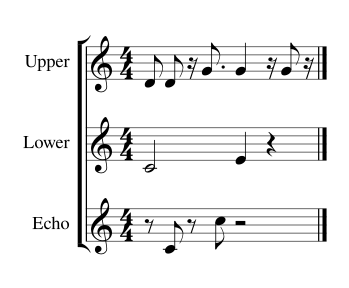

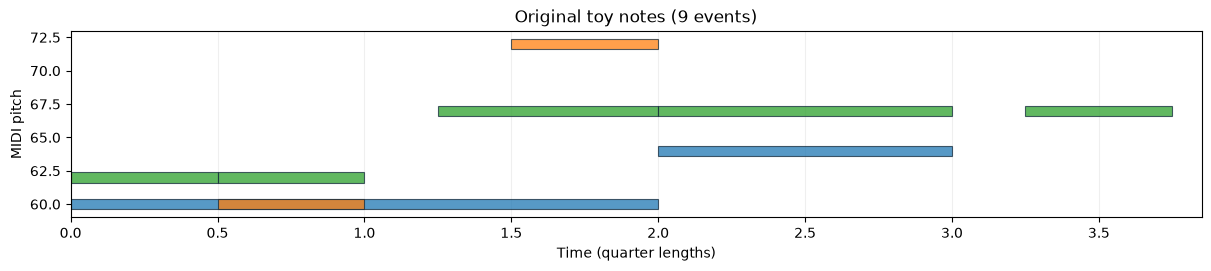

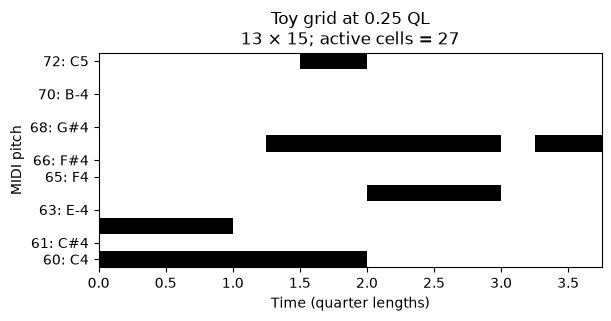

In [2]:
toy_notes = make_roundtrip_example()
toy = create_binary_matrix_bundle(
    toy_notes, source_name="nine-note example",
    resolution_method="manual", manual_resolution=0.25,
    row_order="high_to_low", measure_offsets=[0.0, 4.0],
)
display(toy_notes)
toy_mei_path = find_camat_root() / "camat" / "examples" / "binary_roundtrip_voices.mei"
toy_mei = toy_mei_path.read_text(encoding="utf-8")
with vrv_quiet():
    vrv_set_options(pageWidth=1800, pageHeight=1200, scale=45, breaks="none",
                    adjustPageHeight=True, header="none", removeIds=False, xmlIdSeed=0)
    vrv_load_from_file(str(toy_mei_path))
    toy_svgs = vrv_render_all_pages()
for svg in toy_svgs:
    vrv_display_svg(svg)
fig = plot_note_comparison({"Original toy notes": toy_notes})
display(fig)
plt.close(fig)
fig = plot_binary_comparison({"Toy grid at 0.25 QL": toy})
display(fig)
plt.close(fig)


## 2. Time resolution is a modeling choice

Onsets are floored to a cell boundary; ends are ceiled. The matrix ends at the
latest sounding note end, rounded up to the grid. Each cell spans a half-open
interval `[start, end)`; adjacent note events can therefore form a single run.

Compare 0.125, 0.25, 0.5 and 1.0 QL. **Auto uses the shortest positive duration**,
which is 0.5 QL here, even though onsets at 1.25 and 3.25 require a finer grid.
Auto is not a guarantee that all note boundaries align.

The table reports maximum source-boundary errors *before merging cells*.
Occupied pitch-time is the sum of active cells × resolution: overlapping unisons
are counted once. A finer grid cannot recover boundaries between touching repeats.


,resolution_QL,columns,occupied_pitch_QL,max_onset_error_QL,max_end_error_QL,reconstructed_spans,events_equal,grid_equal
grid,,,,,,,,
0.125 QL,0.125,30,6.75,0.00,0.00,6,False,True
0.25 QL,0.250,15,6.75,0.00,0.00,6,False,True
0.5 QL,0.500,8,7.50,0.25,0.25,5,False,True
1 QL,1.000,4,8.00,0.50,0.50,5,False,True
auto (min duration),0.500,8,7.50,0.25,0.25,5,False,True


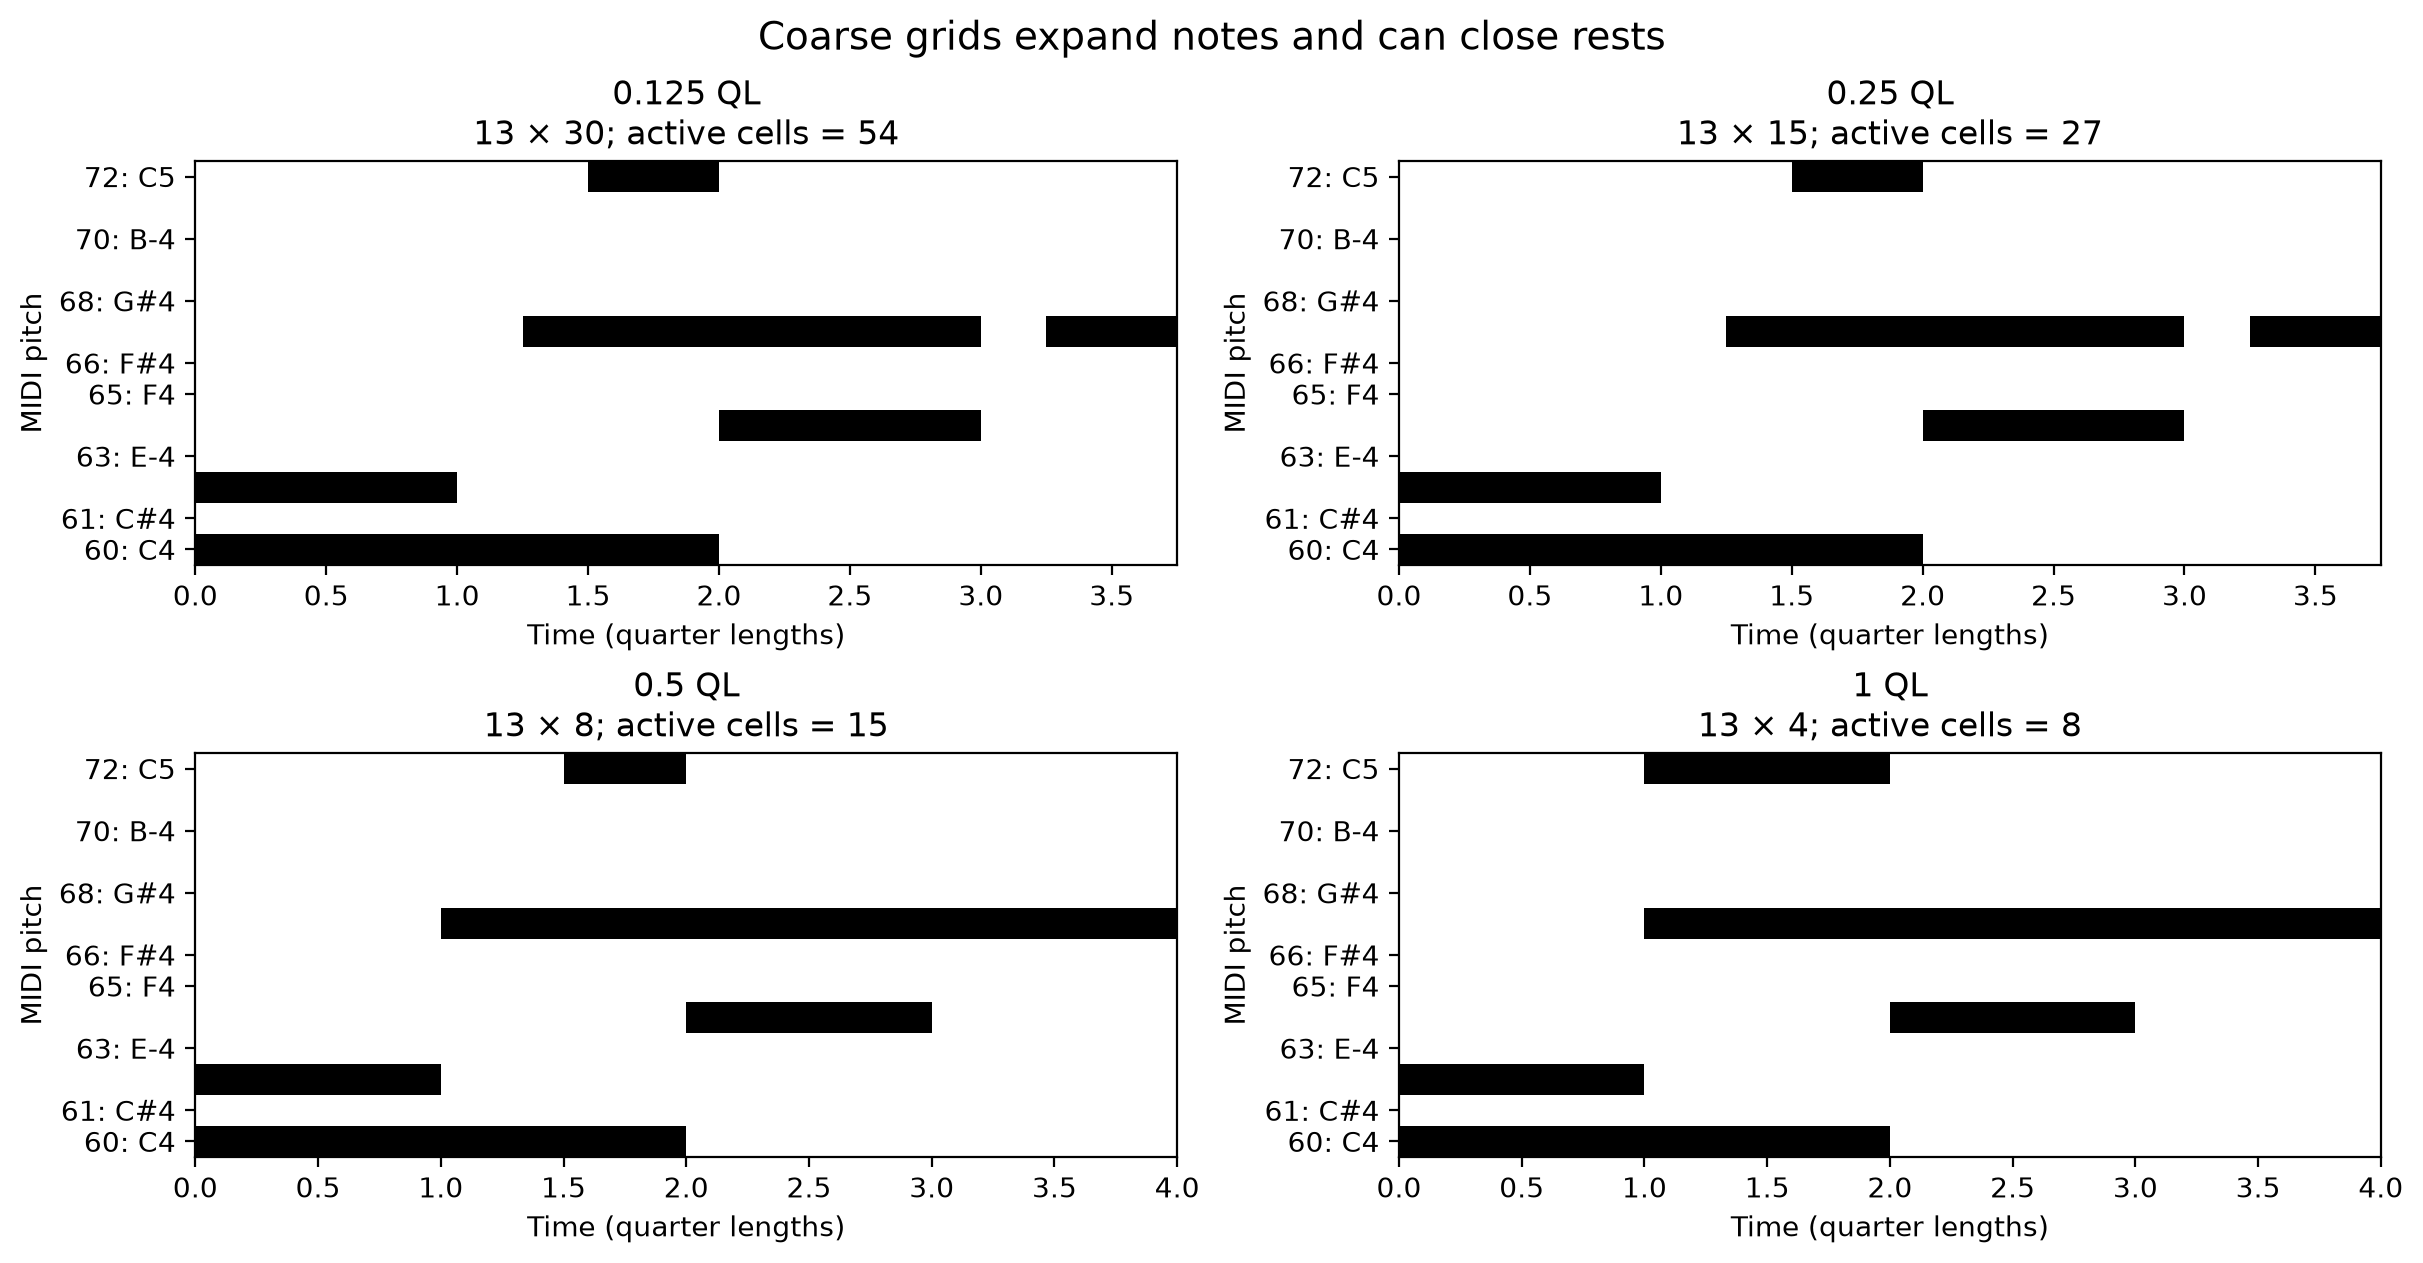

In [3]:
RESOLUTIONS = [0.125, 0.25, 0.5, 1.0]
resolution_report, resolution_bundles = compare_binary_resolutions(toy_notes, RESOLUTIONS)
display(resolution_report)
fig = plot_binary_comparison(
    {name: bundle for name, bundle in resolution_bundles.items() if name != "auto (min duration)"},
    title="Coarse grids expand notes and can close rests",
)
display(fig)
plt.close(fig)


## 3. Which pitches does the representation keep?

Compare **minmax** (only the chosen MIDI range), **full** (all MIDI pitches
0–127), and **chroma** (12 pitch classes, merging octaves). These are three
different representations, so each gets one plot. MIDI always increases upwards.

**Row order changes storage, not the music.** With `high_to_low`, raw row 0
holds the highest pitch; with `low_to_high`, it holds the lowest. A plotting
function that reads the metadata draws both identically. There is no musical
benefit to choosing one over the other; keep one convention throughout a search.

It matters when indexing the array or supplying a kernel: the same raw row
number refers to a different pitch, and a kernel stored in the opposite order
would reverse its contour. The small mapping table below illustrates this
without repeating the same musical plot.

Chroma spans have no unique MIDI octave. Provenance can still identify the
original C4 and C5 notes that contributed to a folded C cell.


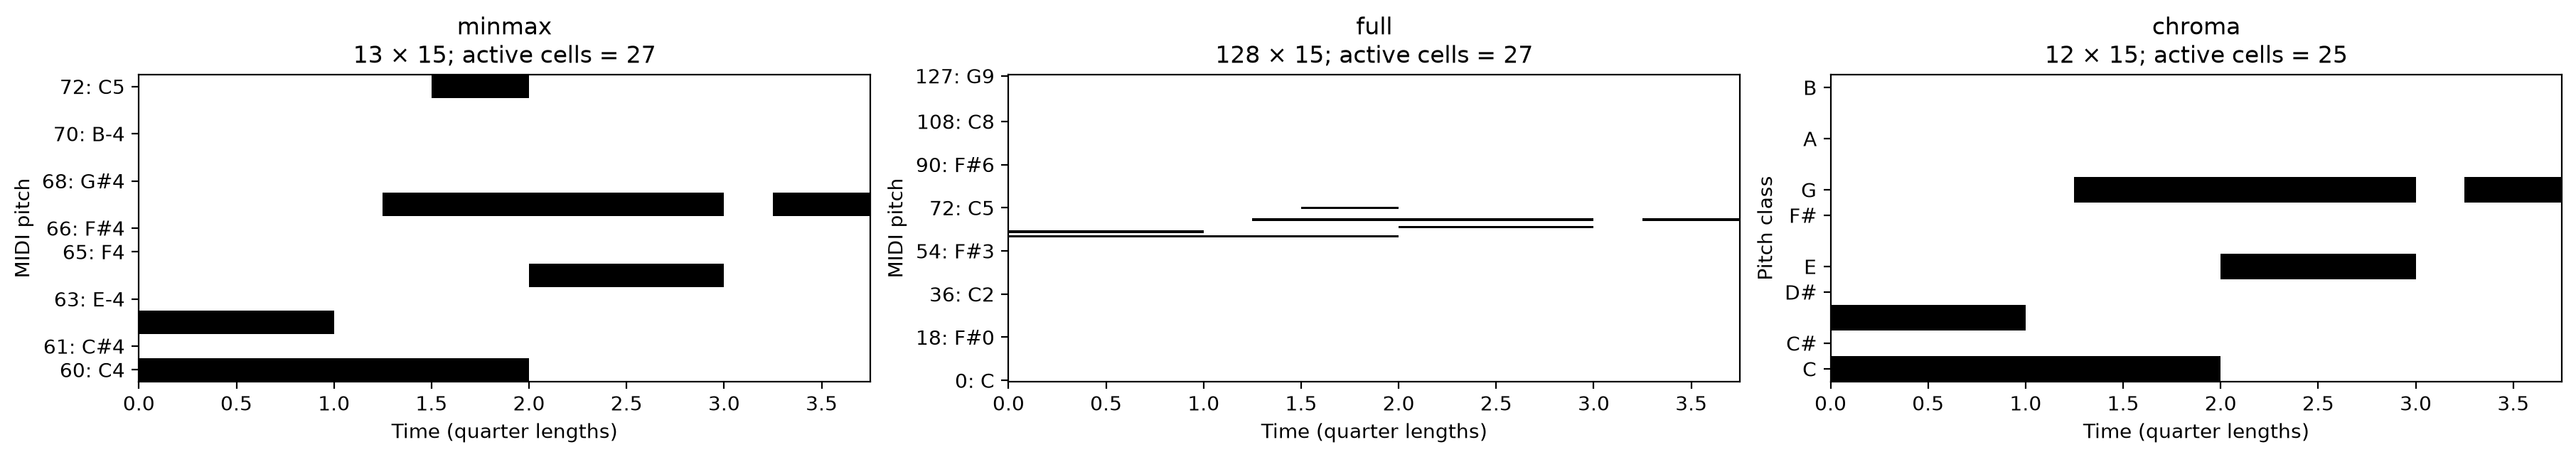

,storage order,pitch at raw row 0,pitch at last row
0,high_to_low,72,60
1,low_to_high,60,72


Chroma C cell at 1.5 QL: original octave identities come from provenance.


,MIDI,Global Onset,Duration,Voice,xml_id
0,60,0.0,2.0,lower,toy-0
1,72,1.5,0.5,echo,toy-7


In [4]:
pitch_bundles = {
    mode: create_binary_matrix_bundle(
        toy_notes, source_name=mode,
        resolution_method="manual", manual_resolution=0.25,
        y_mode=mode, row_order="high_to_low",
    )
    for mode in ["minmax", "full", "chroma"]
}
fig = plot_binary_comparison(pitch_bundles, ncols=3)
display(fig)
plt.close(fig)

low_order = create_binary_matrix_bundle(
    toy_notes, resolution_method="manual", manual_resolution=0.25,
    row_order="low_to_high",
)
np.testing.assert_array_equal(toy.matrix, low_order.matrix[::-1])
display(pd.DataFrame([
    {"storage order": b.meta["row_order"], "pitch at raw row 0": b.meta["row_axis_values"][0],
     "pitch at last row": b.meta["row_axis_values"][-1]}
    for b in [toy, low_order]
]))

chroma = pitch_bundles["chroma"]
c_row = chroma.meta["row_axis_values"].index("C")
c_cell = get_binary_cell_provenance(chroma.meta, c_row, 6, as_dataframe=True)
print("Chroma C cell at 1.5 QL: original octave identities come from provenance.")
display(c_cell["source_df"][["MIDI", "Global Onset", "Duration", "Voice", "xml_id"]])


## 4. Three different roundtrip guarantees

**Cell coverage:** decode contiguous runs, then encode them on the same grid.
Every cell should agree, including silence. **Event equality:** compare the
multiset of (MIDI, onset, duration), including duplicate events. **Source identity:**
voices, spelling, articulation and xml:ids belong to the original source and its
provenance; they are not reconstructed from 0/1 values.

The nine source notes become six spans at 0.25 QL. The table below identifies
which source rows contribute to each span. Splitting by voice recovers the
overlapping unison's identity, but touching repeated notes within a voice still
merge. These audits compare events with the input table, not notation fidelity.


,source_notes,shape,reconstructed_spans,unchanged_events,events_equal,changed_cells,grid_equal
toy,9,"(13, 15)",6,4,False,0,True


,Axis Label,Global Onset,Duration,source_count,source_xml_ids,source_voices
0,D4,0.00,1.00,2,"[toy-2, toy-3]",[upper]
1,C4,0.00,2.00,2,"[toy-0, toy-1]","[lower, echo]"
2,G4,1.25,1.75,2,"[toy-4, toy-6]",[upper]
3,C5,1.50,0.50,1,[toy-7],[echo]
4,E4,2.00,1.00,1,[toy-5],[lower]
5,G4,3.25,0.50,1,[toy-8],[upper]


,source_notes,shape,reconstructed_spans,unchanged_events,events_equal,changed_cells,grid_equal
scope,,,,,,,
all voices merged,9,"(13, 15)",6,4,False,0,True
lower,2,"(13, 15)",2,2,True,0,True
echo,2,"(13, 15)",2,2,True,0,True
upper,5,"(13, 15)",3,1,False,0,True


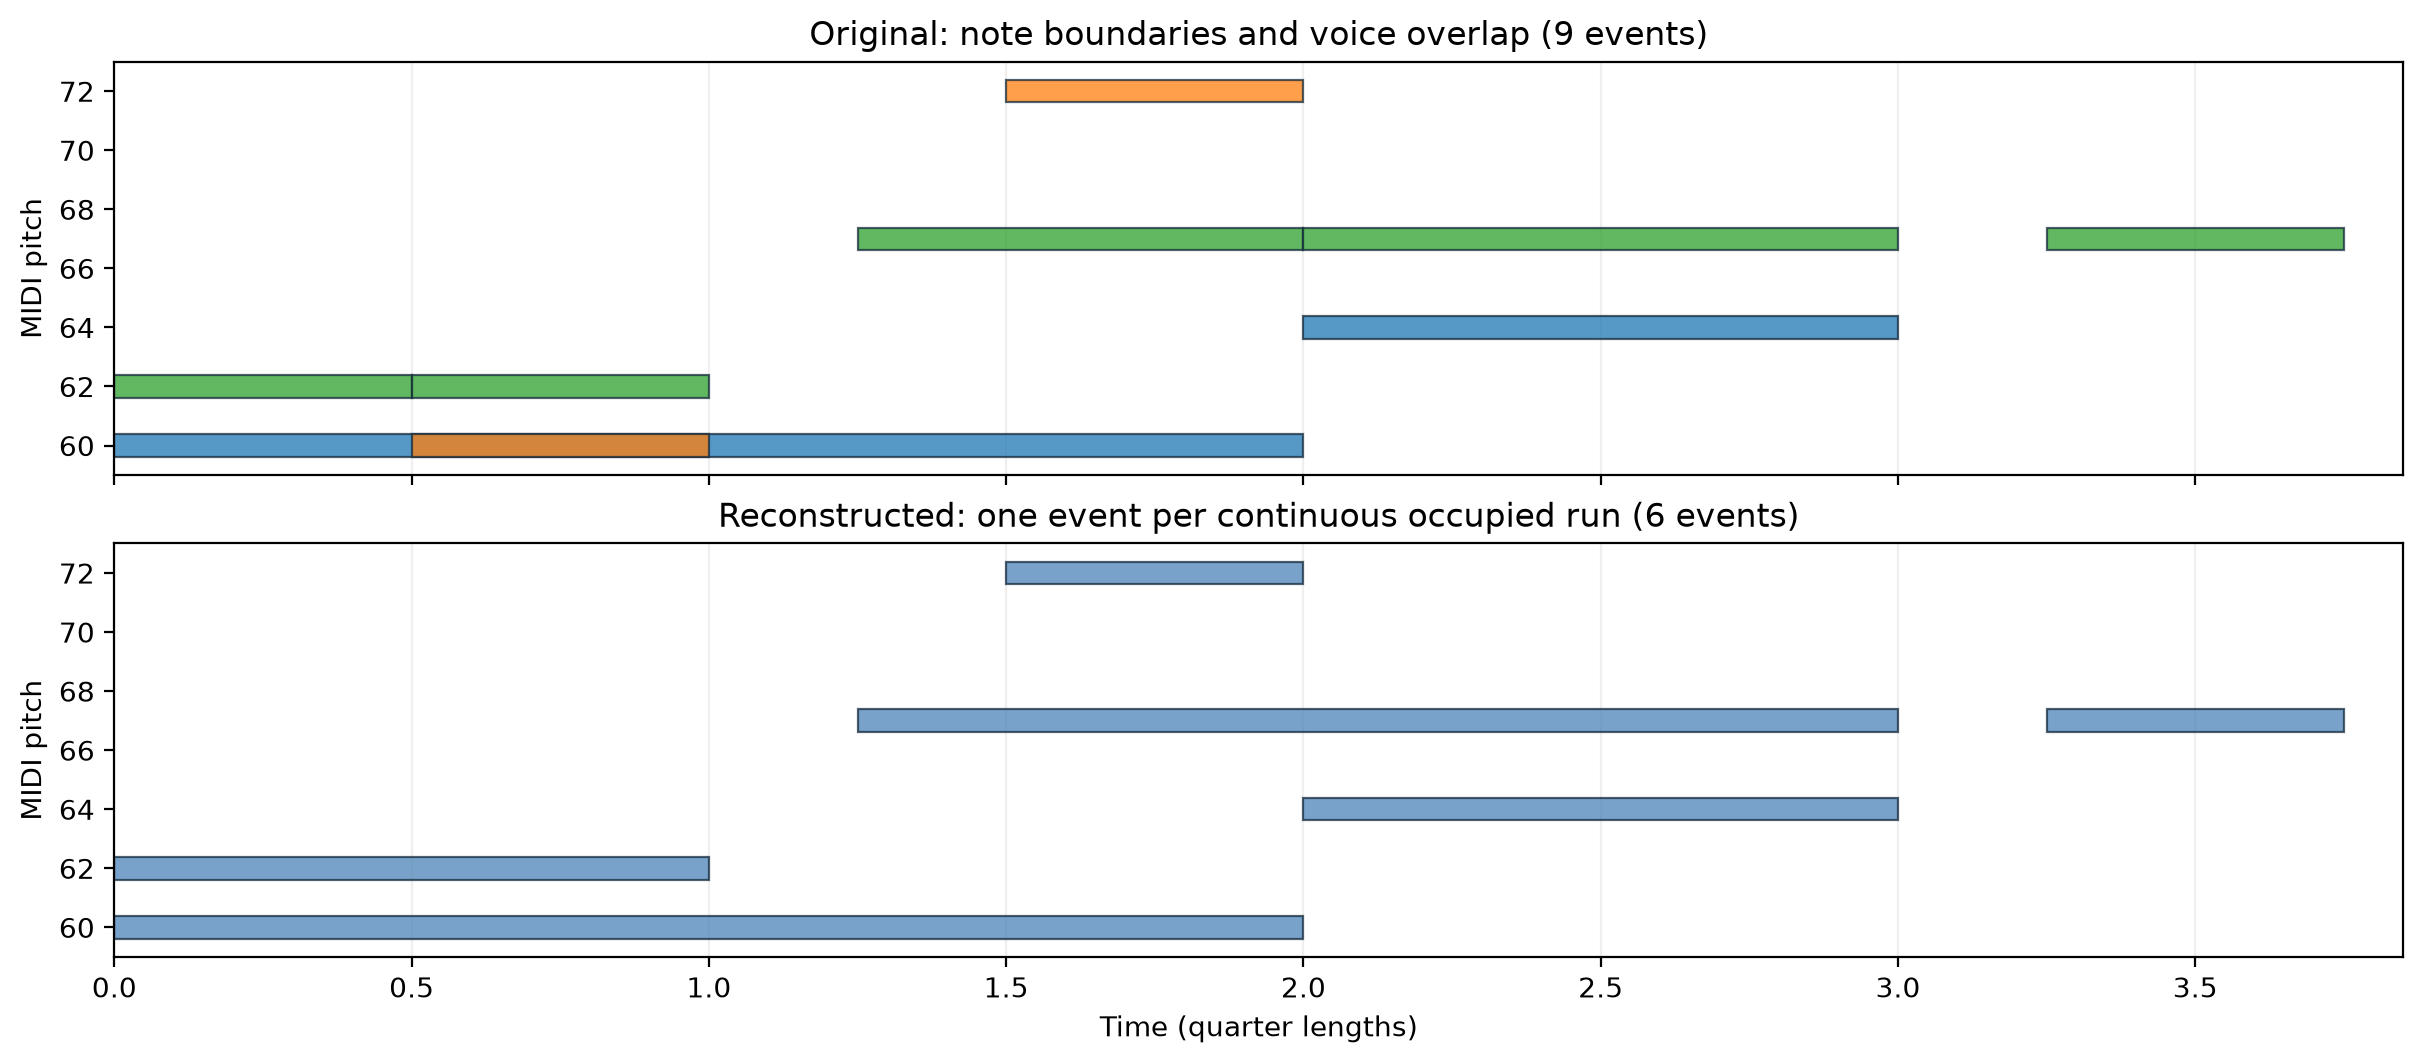

In [5]:
display(pd.DataFrame([audit_binary_roundtrip(toy)], index=["toy"]))
display(describe_binary_span_sources(toy)[
    ["Axis Label", "Global Onset", "Duration", "source_count", "source_xml_ids", "source_voices"]
])
display(compare_voice_roundtrips(toy))

fig = plot_note_comparison({
    "Original: note boundaries and voice overlap": toy_notes,
    "Reconstructed: one event per continuous occupied run": toy.reconstructed_df,
})
display(fig)
plt.close(fig)
assert audit_binary_roundtrip(toy)["grid_equal"]
assert not audit_binary_roundtrip(toy)["events_equal"]


### One cell can have several sources

At C4, 0.5 QL, the binary value is still just 1. Its provenance contains the held
note and the overlapping unison. Source notes retain their full original bounds;
provenance does not trim them to the selected cell.


In [6]:
unison_row = toy.meta["row_axis_values"].index(60)
unison = get_binary_cell_provenance(toy.meta, unison_row, 2, as_dataframe=True)
print(f"Cell ({unison_row}, 2) = {toy.matrix[unison_row, 2]}; source rows = {unison['source_count']}")
display(unison["source_df"])


Cell (12, 2) = 1; source rows = 2


,MIDI,Global Onset,Duration,Voice,Case,xml_id,source_row_position,source_df_index
0,60,0.0,2.0,lower,held C4,toy-0,0,0
1,60,0.5,0.5,echo,overlapping unison,toy-1,1,1


### Search A: a perfect fit assembled across voices

Query C4 for half a QL, then D4 for half a QL. The merged grid contains both
pieces, giving a perfect containment score — but no single voice plays that
melody. Independent voice grids retain the same pitch/time axes and their own
provenance. This is useful when “the same melodic voice” is part of the question.

The table compares all voices. The figures show the merged heatmap and one
voice's heatmap; each circled peak is carried into the binary window at right.
Magenta boxes identify occupied query cells; red crosses identify missing cells.
Extra host notes are ignored by normalized overlap.

The two-row table at the end lists **contributors to the query**, not a
complete score. It contains the second D4 in Upper and the held C4 in Lower.
The score below retains **all nine notes, all three voices and every rest**,
with those two notes highlighted. A highlighted source note keeps its complete
written duration, even if only part of it contributed to the binary match.

This source has a zero-accidental key signature (no sharps or flats to draw),
and a 4/4 meter. Clefs, meter, rests and surrounding notes remain visible.

Even a per-voice occupancy grid still merges touching repeats. Retaining those
boundaries requires the original event table or additional onset/offset channels.


,scope,best_score,grid_shape
0,merged,1.0,"(13, 15)"
1,lower,0.5,"(13, 15)"
2,echo,0.5,"(13, 15)"
3,upper,0.5,"(13, 15)"


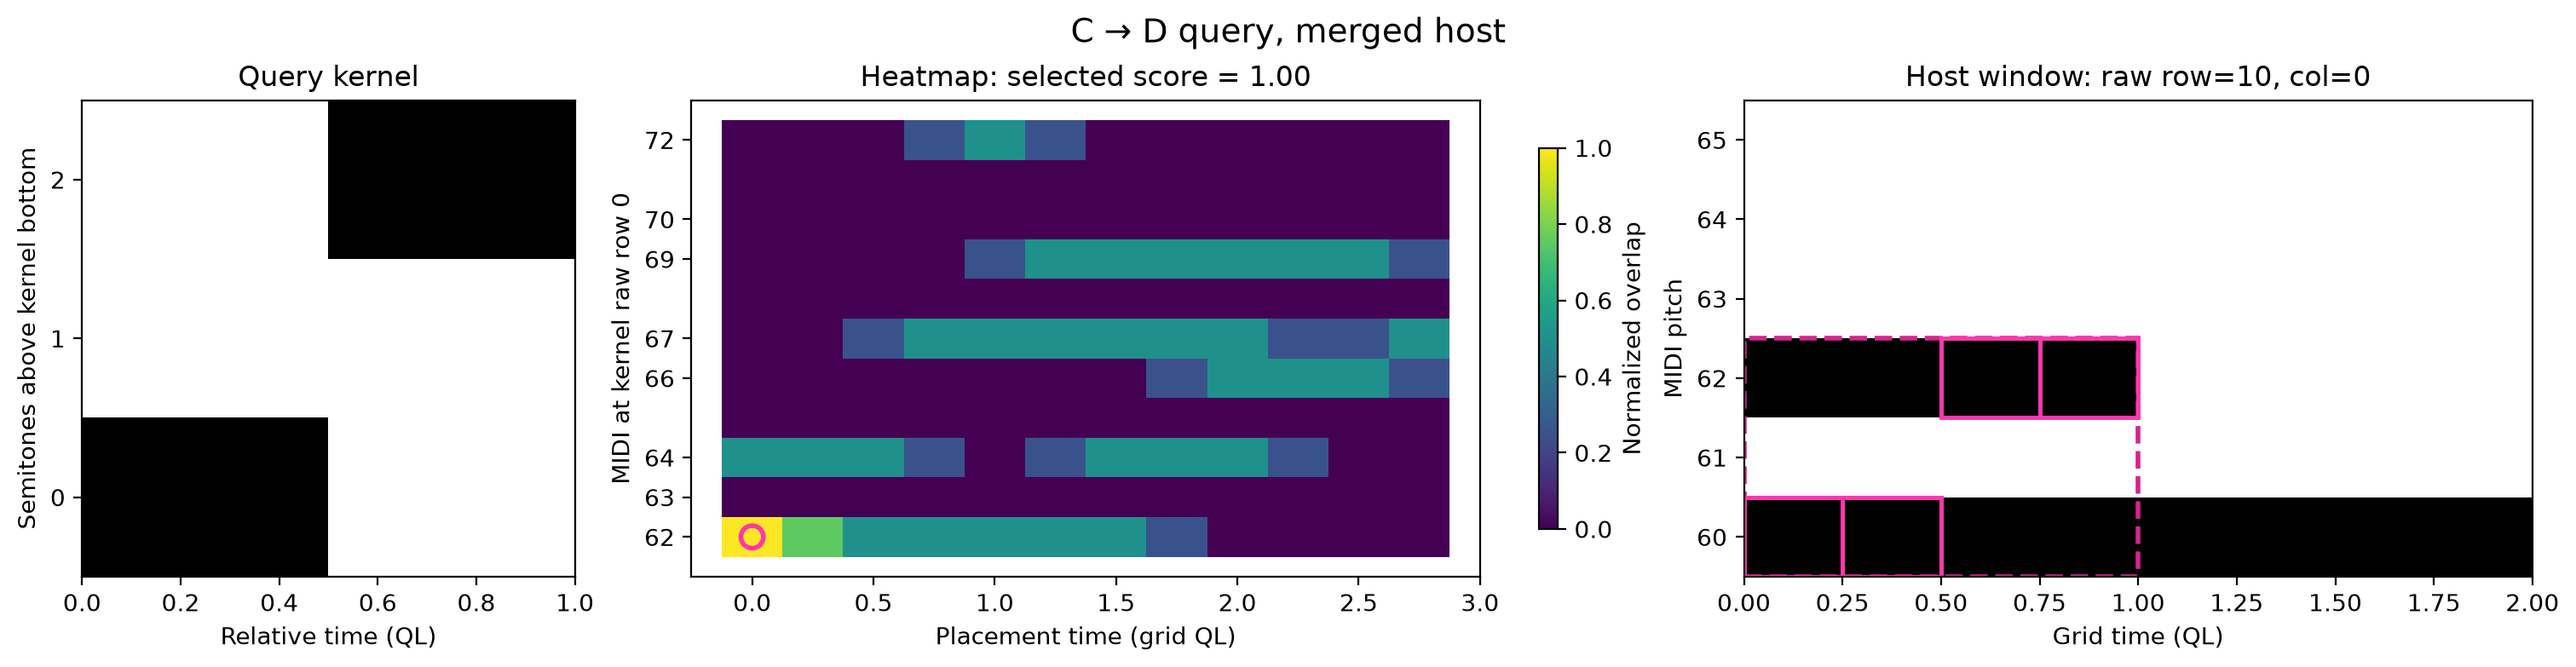

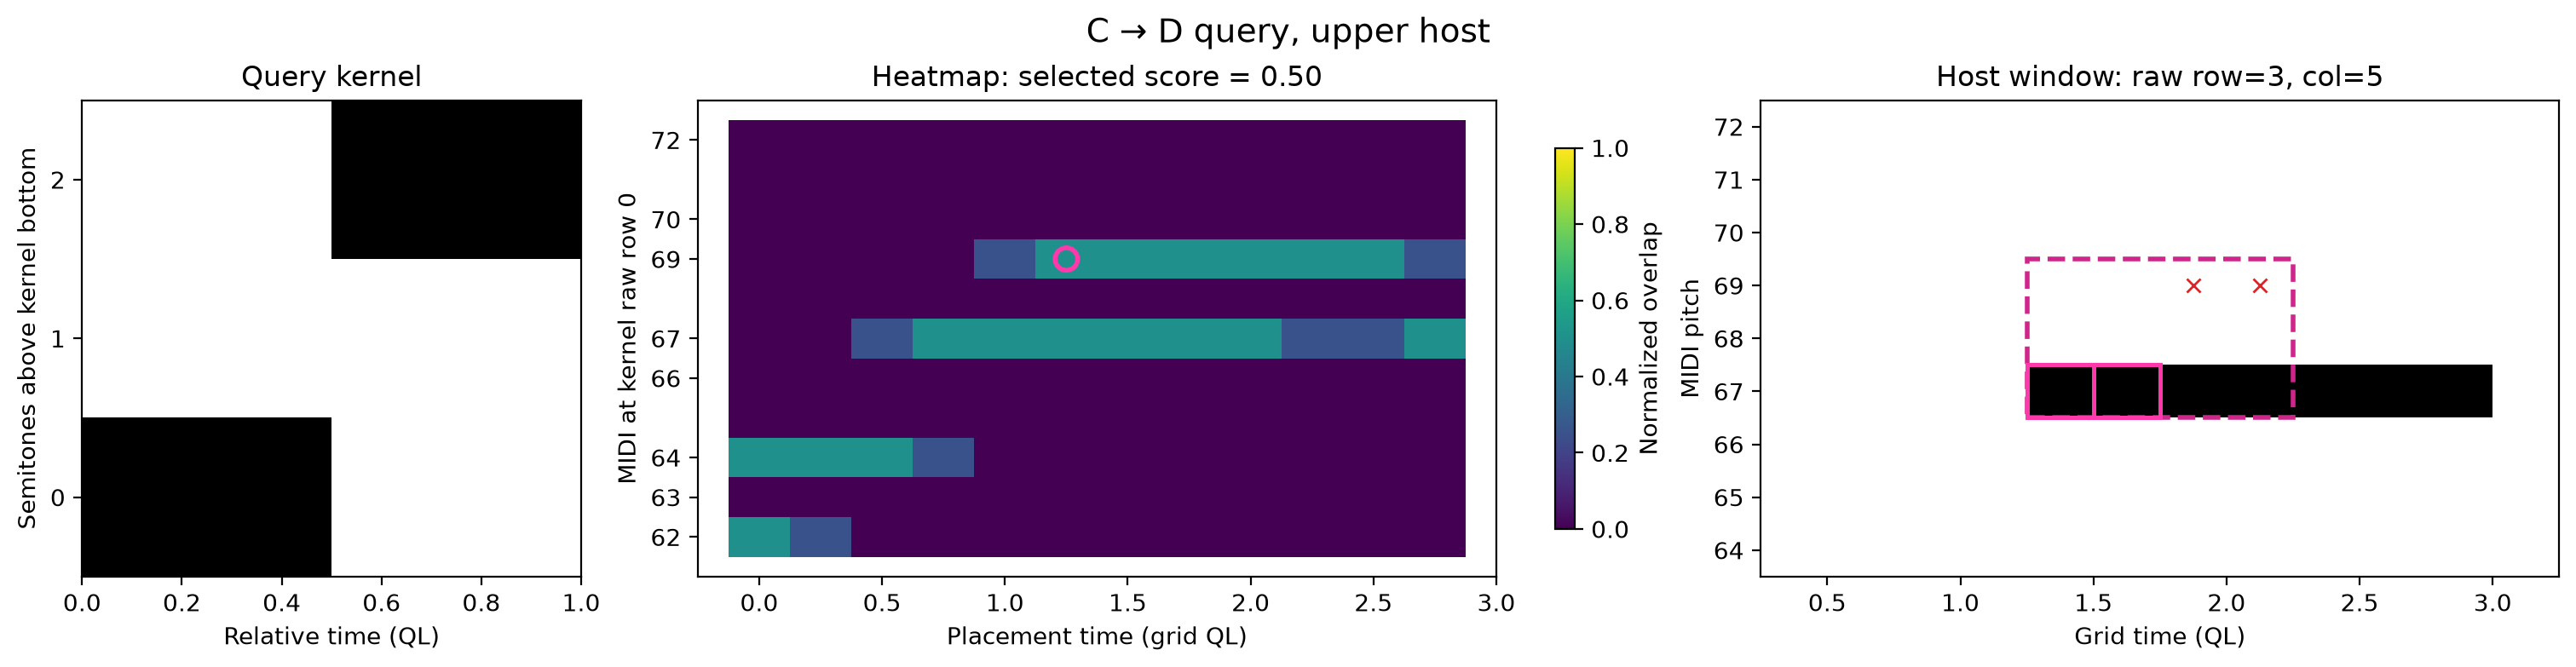

Two contributing source notes — highlighted within the complete score below:


,xml_id,Voice,MIDI,Global Onset,Duration
0,toy-3,upper,62,0.5,0.5
1,toy-0,lower,60,0.0,2.0


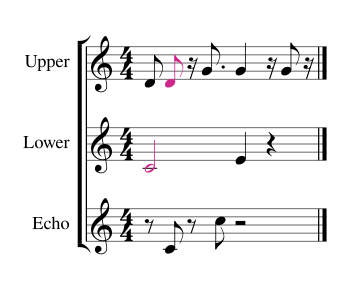

In [7]:
voice_grids = split_binary_voices(toy)
# Raw rows are high_to_low here: D4 above C4.
stitched_kernel = np.zeros((3, 4), dtype=int)
stitched_kernel[2, :2] = 1  # lower pitch first
stitched_kernel[0, 2:] = 1  # pitch +2 semitones second
toy_search_hosts = {"merged": toy, **voice_grids}
toy_searches = {name: find_binary_matches(host, stitched_kernel) for name, host in toy_search_hosts.items()}
display(pd.DataFrame([
    {"scope": name, "best_score": result["matches"].iloc[0]["score"], "grid_shape": toy_search_hosts[name].matrix.shape}
    for name, result in toy_searches.items()
]))
assert toy_searches["merged"]["matches"].iloc[0]["score"] == 1.0
assert all(result["matches"].iloc[0]["score"] < 1.0 for name, result in toy_searches.items() if name != "merged")

for scope in ["merged", "upper"]:
    fig = plot_binary_search_trace(
        toy_search_hosts[scope], stitched_kernel, toy_searches[scope],
        title=f"C → D query, {scope} host",
    )
    display(fig)
    plt.close(fig)

toy_hit = toy_searches["merged"]["matches"].iloc[0]
toy_trace = binary_match_sources(toy, stitched_kernel, toy_hit["row"], toy_hit["col"])
print("Two contributing source notes — highlighted within the complete score below:")
display(toy_trace["matched_notes"][["xml_id", "Voice", "MIDI", "Global Onset", "Duration"]])
with vrv_quiet():
    vrv_set_options(pageWidth=1800, pageHeight=1200, scale=45, breaks="none", adjustPageHeight=True, header="none")
    stitched_context = vrv_render_source_context(
        toy_trace["matched_notes"], mei_xml=toy_mei, highlight_color="#cf268c", display=True,
    )


## 5. Apply the same workflow to a real score

Choose a local common-notation MEI or a URL. `RUN_FETCH = False` never downloads.
For the default Bach URL, an empty cache selects CAMAT's bundled short example
and prints that choice; a different uncached URL skips this section.

The source controls apply here; the earlier toy experiments stay fixed for
comparison. `MANUAL_RESOLUTION` is used only with `RESOLUTION_METHOD = "manual"`.
The notebook handles chroma through pitch-class spans and provenance instead of
pretending its rows are MIDI pitches.

**Pickup handling:** CAMAT's source timeline places Bach's one-QL pickup at
−1 and its first full bar at 0. We keep all sounding notes and rebase **both
notes and measure boundaries**: grid time 0 is the pickup, and the first full
bar begins at grid time 1. `Source Global Onset` retains the original coordinate;
source time = grid time + `source_time_origin`. Local onset and xml:id stay intact.


In [8]:
ROOT = find_camat_root()
BACH_SAMPLE_URL = (
    "https://raw.githubusercontent.com/music-encoding/sample-encodings/"
    "main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei"
)
MEI_SOURCE = BACH_SAMPLE_URL  # or a local .mei path
RUN_FETCH = False
PLOTTING_BACKEND = "bokeh"  # "plt" for saved static figures; "bokeh" for interactive hover
RESOLUTION_METHOD = "manual"  # "manual" | "auto" | "standard"
MANUAL_RESOLUTION = 0.25
Y_MODE = "minmax"  # "minmax" | "full" | "chroma"
ROW_ORDER = "high_to_low"  # "high_to_low" | "low_to_high"

mei_path = resolve_mei_source(MEI_SOURCE, fetch=RUN_FETCH, shared_cache=True, repo_root=ROOT)
if mei_path is None and MEI_SOURCE == BACH_SAMPLE_URL:
    mei_path = ROOT / "camat" / "examples" / "facsimile_viewer_demo.mei"
    print("Bach is not cached; using bundled facsimile_viewer_demo.mei.")

results = df_pitch = df_events = df_pitch_grid = binary = None
measure_offsets = None
if mei_path is None:
    print("Source section skipped: choose a local MEI or enable RUN_FETCH for your URL.")
else:
    results, dfs_by_name, _last_df = parse_files(
        [str(mei_path)], backend="none",
        display_preview_df_pitch=False, display_preview_df_events=False,
        include_xml_ids=True, parse_enharmonic=True,
        quiet_native_warnings=True, use_remote_cache=True,
    )
    df_pitch, df_events = results[0]["df_pitch"], results[0]["df_events"]
    source_measure_offsets = results[0].get("measure_offsets")
    sounding_notes = df_pitch[df_pitch["Duration"] > 0].copy()
    if sounding_notes.empty:
        df_pitch_grid = sounding_notes
        measure_offsets, source_time_origin = [], 0.0
    else:
        df_pitch_grid, measure_offsets, source_time_origin = prepare_binary_timeline(
            sounding_notes, source_measure_offsets,
        )
    print(f"Grid time 0 = source {source_time_origin:g} QL; measure starts: {measure_offsets[:5]}")
    print(f"Source: {mei_path.name}")
    print(f"Pitch rows: {len(df_pitch)}; grid input: {len(df_pitch_grid)}; omitted: {len(df_pitch) - len(df_pitch_grid)}")
    print(f"Event rows (including rests etc.): {len(df_events)}")
    display(df_pitch.head(8))
    if df_pitch_grid.empty:
        print("No positive-duration notes; source grid skipped.")
    else:
        binary = create_binary_matrix_bundle(
            df_pitch_grid, source_name=mei_path.stem,
            measure_offsets=measure_offsets,  # explicit even when the display name differs
            resolution_method=RESOLUTION_METHOD, manual_resolution=MANUAL_RESOLUTION,
            y_mode=Y_MODE, row_order=ROW_ORDER, include_provenance=True,
            hover_fields=["MIDI", "Voice", "xml_id", "source_rows"],
        )
        binary.meta["source_time_origin"] = source_time_origin
        display(df_pitch_grid[["Measure", "Local Onset", "Source Global Onset", "Global Onset", "Duration", "Pitch"]].head(10))
        binary.print_summary()
        draw_piano_roll(
            df_pitch_grid, measure_offsets=measure_offsets, backend=PLOTTING_BACKEND,
            colorize_voices=True, plot_width=1100, plot_height=340,
        )


Processing (verovio): e871590b3deb571b.mei -> 00_e871590b3deb571b
Dropped weaker duplicate MEI text events: 10 row(s) without usable anchors.
Extracted non-barline MEI events: 99 event(s), types=['fermata', 'lyric', 'measure', 'slur', 'tie'].
Grid time 0 = source -1 QL; measure starts: [0.0, 1.0, 5.0, 9.0, 13.0]
Source: e871590b3deb571b.mei
Pitch rows: 235; grid input: 235; omitted: 0
Event rows (including rests etc.): 99


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,3.0,-1.0,0.5,D4,D4,62,P2 - Voice 2,d1e93,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,0.5,<NA>
1,1,3.0,-1.0,1.0,F#4,F#4,66,P2 - Voice 1,d1e92,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
2,1,3.0,-1.0,1.0,A4,A4,69,P1 - Voice 2,d1e91,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
3,1,3.0,-1.0,1.0,D5,D5,74,P1 - Voice 1,d1e64,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
4,1,3.5,-0.5,0.5,C#4,C#4,61,P2 - Voice 2,d1e94,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,0.5,<NA>
5,2,0.0,0.0,1.0,B3,B3,59,P2 - Voice 2,d1e59,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
6,2,0.0,0.0,1.0,D4,D4,62,P1 - Voice 2,d1e487,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
7,2,0.0,0.0,1.0,F#4,F#4,66,P2 - Voice 1,d1e54,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>


,Measure,Local Onset,Source Global Onset,Global Onset,Duration,Pitch
0,1,3.0,-1.0,0.0,0.5,D4
1,1,3.0,-1.0,0.0,1.0,F#4
2,1,3.0,-1.0,0.0,1.0,A4
3,1,3.0,-1.0,0.0,1.0,D5
4,1,3.5,-0.5,0.5,0.5,C#4
5,2,0.0,0.0,1.0,1.0,B3
6,2,0.0,0.0,1.0,1.0,D4
7,2,0.0,0.0,1.0,1.0,F#4
8,2,0.0,0.0,1.0,1.0,D5
9,2,1.0,1.0,2.0,0.5,A3


--- Metadata (create_binary_matrix) ---
  binary_col_index_direction: left_to_right
  binary_coordinate_system: raw_matrix_indices
  binary_row_index_direction: top_to_bottom
  midi_high: 74
  midi_low: 38
  min_positive_duration: 0.25
  num_cols: 192
  num_rows: 37
  origin: upper
  provenance:
    source_row_count: 235
    active_cell_count: 746
    source_columns: ['Measure', 'Local Onset', 'Global Onset', 'Duration', 'Pitch', 'Pitch Enharmonic', 'MIDI', 'Voice', 'xml_id', 'grace', 'tied', 'slurred', 'tuplet', 'fermata', 'articulations', 'ornaments', 'technical', 'Logical Duration', 'Performed Duration', 'Source Global Onset']
  resolution: 0.25
  row_axis_labels: ['D5', 'C#5', 'C5', 'B4', 'B-4', 'A4', 'G#4', 'G4', 'F#4', 'F4', 'E4', 'E-4', 'D4', 'C#4', 'C4', 'B3', 'B-3', 'A3', 'G#3', 'G3', 'F#3', 'F3', 'E3', 'E-3', 'D3', 'C#3', 'C3', 'B2', 'B-2', 'A2', 'G#2', 'G2', 'F#2', 'F2', 'E2', 'E-2', 'D2']
  row_axis_values: [74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58

## 6. Audit the source roundtrip

The source table is compared with reconstructed spans using the selected grid.
The merged and per-voice audits show whether loss is caused by combining voices
or already occurs inside one voice. Resolution errors remain possible in either case.

The second table lists only spans with **multiple contributing source notes**.
This makes a lower reconstructed count inspectable: follow its source IDs and
voices to see touching repetitions or unisons. At coarse resolutions, short
rests can also disappear. In chroma mode, octave folding adds another source of merging.


In [9]:
source_span_report = None
if binary is None:
    print("Skipped: no source grid.")
else:
    display(compare_voice_roundtrips(binary))
    source_span_report = describe_binary_span_sources(binary)
    merged_spans = source_span_report[source_span_report["source_count"] > 1]
    print(f"{len(merged_spans)} occupied runs contain multiple source notes.")
    display(merged_spans[
        ["Axis Label", "Global Onset", "Duration", "source_count", "source_xml_ids", "source_voices"]
    ].head(15))
    if binary.meta["y_mode"] == "chroma":
        print("Chroma: decode class spans and inspect original MIDI through provenance.")
        display(binary.decoded_df.head(12))
    else:
        source_audit = audit_binary_roundtrip(binary)
        assert source_audit["grid_equal"], source_audit
        reconstructed_df = binary_matrix_to_df_from_meta(binary.matrix, binary.meta)
        print(f"Original {len(df_pitch_grid)} notes → {len(reconstructed_df)} reconstructed spans.")
        draw_piano_roll(
            reconstructed_df.assign(Pitch=reconstructed_df["MIDI"].map(camat.midi_to_name)),
            measure_offsets=binary.measure_offsets,
            backend=PLOTTING_BACKEND, colorize_voices=False,
            plot_width=1100, plot_height=300,
        )


,source_notes,shape,reconstructed_spans,unchanged_events,events_equal,changed_cells,grid_equal
scope,,,,,,,
all voices merged,235,"(37, 192)",202,182,False,0,True
P2 - Voice 2,61,"(37, 192)",59,57,False,0,True
P2 - Voice 1,63,"(37, 192)",54,48,False,0,True
P1 - Voice 2,59,"(37, 192)",52,46,False,0,True
P1 - Voice 1,52,"(37, 192)",48,45,False,0,True


20 occupied runs contain multiple source notes.


,Axis Label,Global Onset,Duration,source_count,source_xml_ids,source_voices
0,D5,0.0,3.00,3,"[d1e64, d1e366, d1e390]",[P1 - Voice 1]
2,F#4,0.0,2.00,2,"[d1e92, d1e54]",[P2 - Voice 1]
5,D4,1.0,1.50,2,"[d1e487, d1e501]",[P1 - Voice 2]
6,B3,1.0,1.50,2,"[d1e59, d1e55]","[P2 - Voice 2, P2 - Voice 1]"
70,D4,15.0,2.00,4,"[d1e1237, d1e1321, d1e1523, d1e1545]","[P1 - Voice 1, P1 - Voice 2]"
71,F#3,15.0,1.50,2,"[d1e1958, d1e2190]",[P2 - Voice 1]
72,D3,15.0,1.50,2,"[d1e2030, d1e2227]",[P2 - Voice 2]
94,E3,20.0,3.00,3,"[d1e2519, d1e2623, d1e2864]","[P2 - Voice 1, P2 - Voice 2]"
98,D4,23.0,3.00,4,"[d1e2073, d1e2130, d1e2892, d1e3170]","[P1 - Voice 1, P1 - Voice 2, P2 - Voice 1]"
112,A3,26.0,3.00,4,"[d1e3184, d1e3245, d1e3198, d1e3212]","[P2 - Voice 1, P2 - Voice 2]"


Original 235 notes → 202 reconstructed spans.


## 7. Select a fragment as a kernel, then find its best-fitting window

A **kernel** is the small pattern we ask for; a **host** is the larger binary
representation searched. Here we select a voice and time interval from the
score, copy its occupied bounding box as the kernel, and slide that kernel
over each voice's complete grid. Internal rests and semitone spacing stay intact.

The search returns scores and raw (row, column) placements. A highlighted
**window** marks one of those candidate placements: its position comes from the
search, and its size comes from the kernel. It is not an arbitrary selection.

The figure shows the query, a circled heatmap peak, and that exact placement on
the host. `MATCH_RANK = 0` inspects the highest-ranked result; try another rank
to follow a different candidate. Scores can tie, and extra host notes do not
reduce normalized overlap.

Because the query was taken from this same host, its original location must
score 1. This is a known-answer check of the search and coordinate mapping.
Other high scores may indicate a repeated or transposed fragment; they do not
establish uniqueness. The next section explains which source notes actually
contributed to the highlighted window.

`SEARCH_VOICE = None` chooses the highest voice by average pitch.
`QUERY_START_QL` / `QUERY_END_QL` select **grid time**, including the pickup.
This search uses MIDI rows; choose minmax or full in section 5 to run it.


,voice,best_score
0,P2 - Voice 2,0.500
1,P2 - Voice 1,0.750
2,P1 - Voice 2,0.625
3,P1 - Voice 1,1.000


Query voice: P1 - Voice 1; original raw placement: (0, 0); shape: (6, 16)


,score,row,col,grid_onset_QL,source_onset_QL,anchor_MIDI
0,1.0000,0,0,0.00,-1.00,74
1,0.8125,0,1,0.25,-0.75,74
2,0.6250,0,2,0.50,-0.50,74
3,0.5625,0,3,0.75,-0.25,74
4,0.5000,0,4,1.00,0.00,74
5,0.5000,0,106,26.50,25.50,74
6,0.5000,0,107,26.75,25.75,74
7,0.5000,0,108,27.00,26.00,74
8,0.5000,1,104,26.00,25.00,73
9,0.5000,3,40,10.00,9.00,71


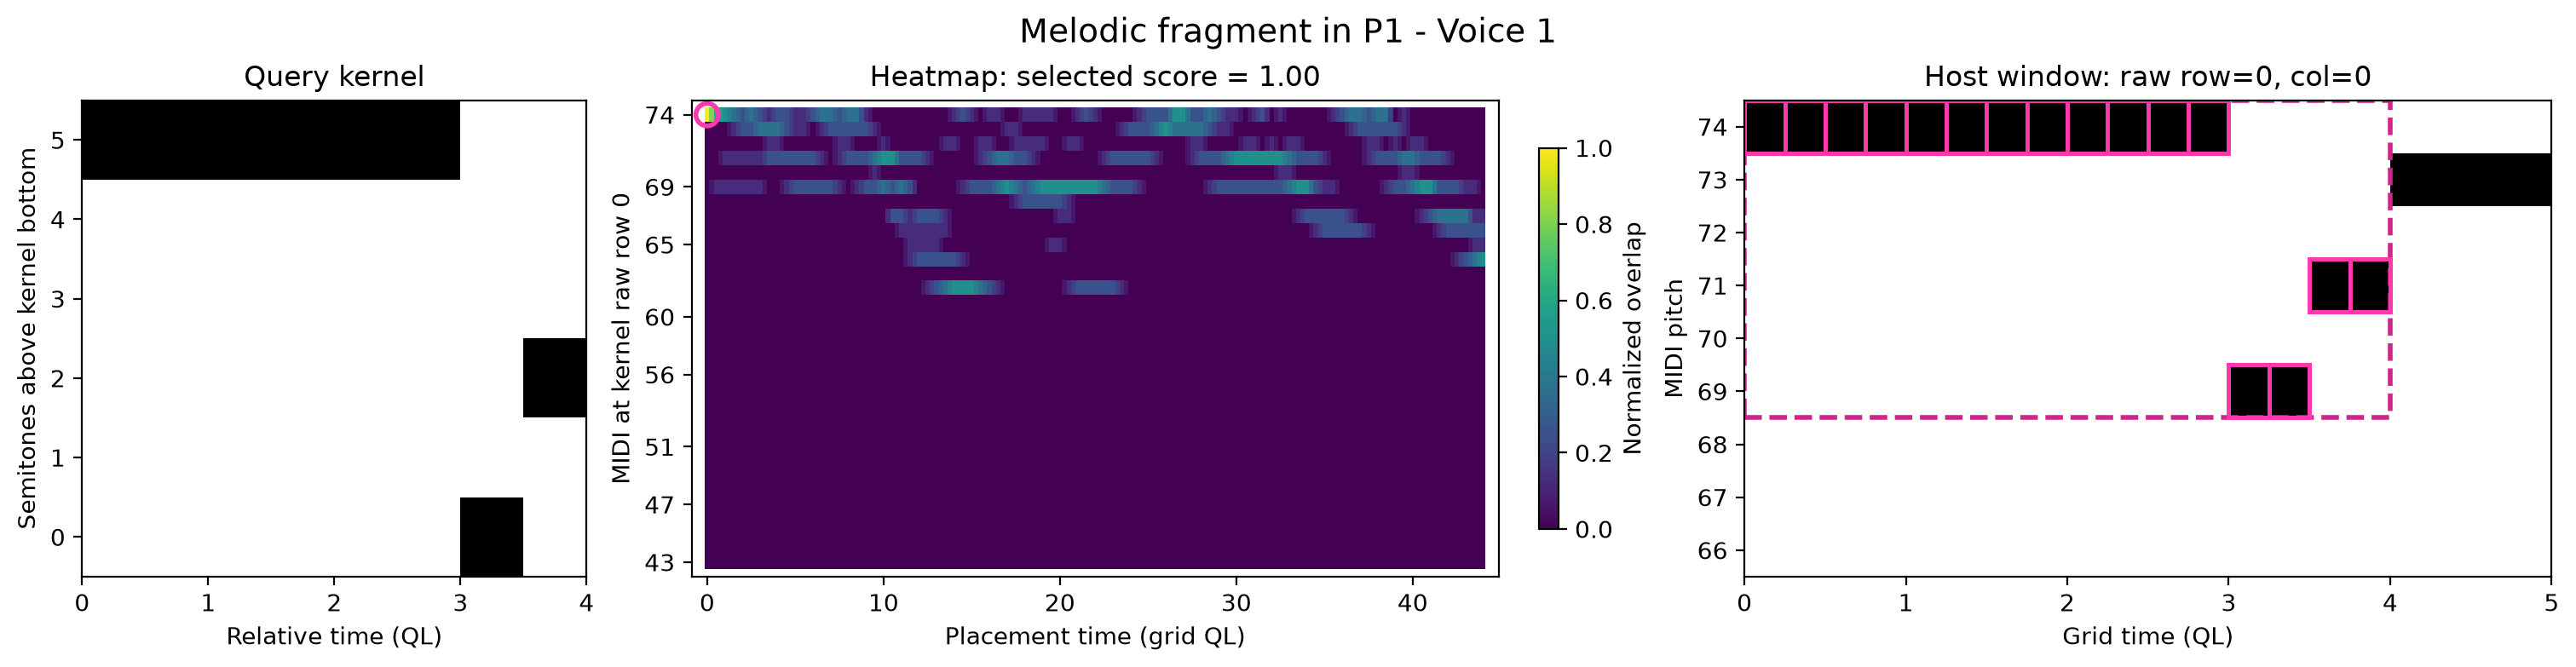

Score 1.00; missing query cells: 0


In [10]:
SEARCH_VOICE = None
QUERY_START_QL, QUERY_END_QL = 0.0, 4.0  # grid time: Bach's pickup begins at 0
MATCH_RANK = 0
source_search = None
trace = None
WINDOW_COLOR = "#cf268c"

if binary is None or binary.meta["y_mode"] == "chroma":
    print("Real-score MIDI search skipped; the toy search above still runs.")
else:
    source_voices = split_binary_voices(binary)
    selected_voice = SEARCH_VOICE or str(df_pitch_grid.groupby("Voice")["MIDI"].mean().idxmax())
    if selected_voice not in source_voices:
        raise ValueError(f"Choose a SEARCH_VOICE from {list(source_voices)}")
    search_host = source_voices[selected_voice]
    step = binary.meta["resolution"]
    first_col = max(0, int(np.floor(QUERY_START_QL / step)))
    last_col = min(binary.matrix.shape[1], int(np.ceil(QUERY_END_QL / step)))
    fragment = search_host.matrix[:, first_col:last_col]
    active_r, active_c = np.nonzero(fragment)
    if not active_r.size:
        print("Query interval is empty; adjust its voice or time bounds.")
    else:
        kr0, kr1 = int(active_r.min()), int(active_r.max()) + 1
        kc0, kc1 = first_col + int(active_c.min()), first_col + int(active_c.max()) + 1
        melody_kernel = search_host.matrix[kr0:kr1, kc0:kc1].copy()
        voice_searches = {name: find_binary_matches(host, melody_kernel, top_n=10) for name, host in source_voices.items()}
        display(pd.DataFrame([
            {"voice": name, "best_score": result["matches"].iloc[0]["score"]}
            for name, result in voice_searches.items()
        ]))
        source_search = voice_searches[selected_voice]
        assert np.isclose(source_search["scores"][kr0, kc0], 1.0)
        print(f"Query voice: {selected_voice}; original raw placement: ({kr0}, {kc0}); shape: {melody_kernel.shape}")
        display(source_search["matches"].head(10))
        fig = plot_binary_search_trace(search_host, melody_kernel, source_search, rank=MATCH_RANK,
                                       title=f"Melodic fragment in {selected_voice}")
        display(fig)
        plt.close(fig)
        hit = source_search["matches"].iloc[MATCH_RANK]
        trace = binary_match_sources(search_host, melody_kernel, hit["row"], hit["col"])
        print(f"Score {trace['score']:.2f}; missing query cells: {len(trace['missing_cells'])}")


### What does that rectangle highlight?

The rectangle bounds a **pitch/time window**, not a new note event. It contains
occupied cells, empty cells and possibly extra host notes.

Provenance answers two different questions: which notes contributed anywhere
in the rectangle, and which notes contributed to occupied **query** cells.
The table and magenta piano-roll outlines below show the latter. The background
piano roll includes all voices, so accompaniment stays visible.

A note may extend beyond the selected cell or window. We retain its original
onset, duration and xml:id: highlighting part of its occupancy does not cut the
source note into a new event. The next render uses those IDs on the original score.


Raw window: rows 0:6, columns 0:16.
Source notes in rectangle: 5; query contributors: 5.


,xml_id,Voice,MIDI,Source Global Onset,Global Onset,Duration
0,d1e64,P1 - Voice 1,74,-1.0,0.0,1.0
1,d1e366,P1 - Voice 1,74,0.0,1.0,1.0
2,d1e390,P1 - Voice 1,74,1.0,2.0,1.0
3,d1e442,P1 - Voice 1,71,2.5,3.5,0.5
4,d1e414,P1 - Voice 1,69,2.0,3.0,0.5


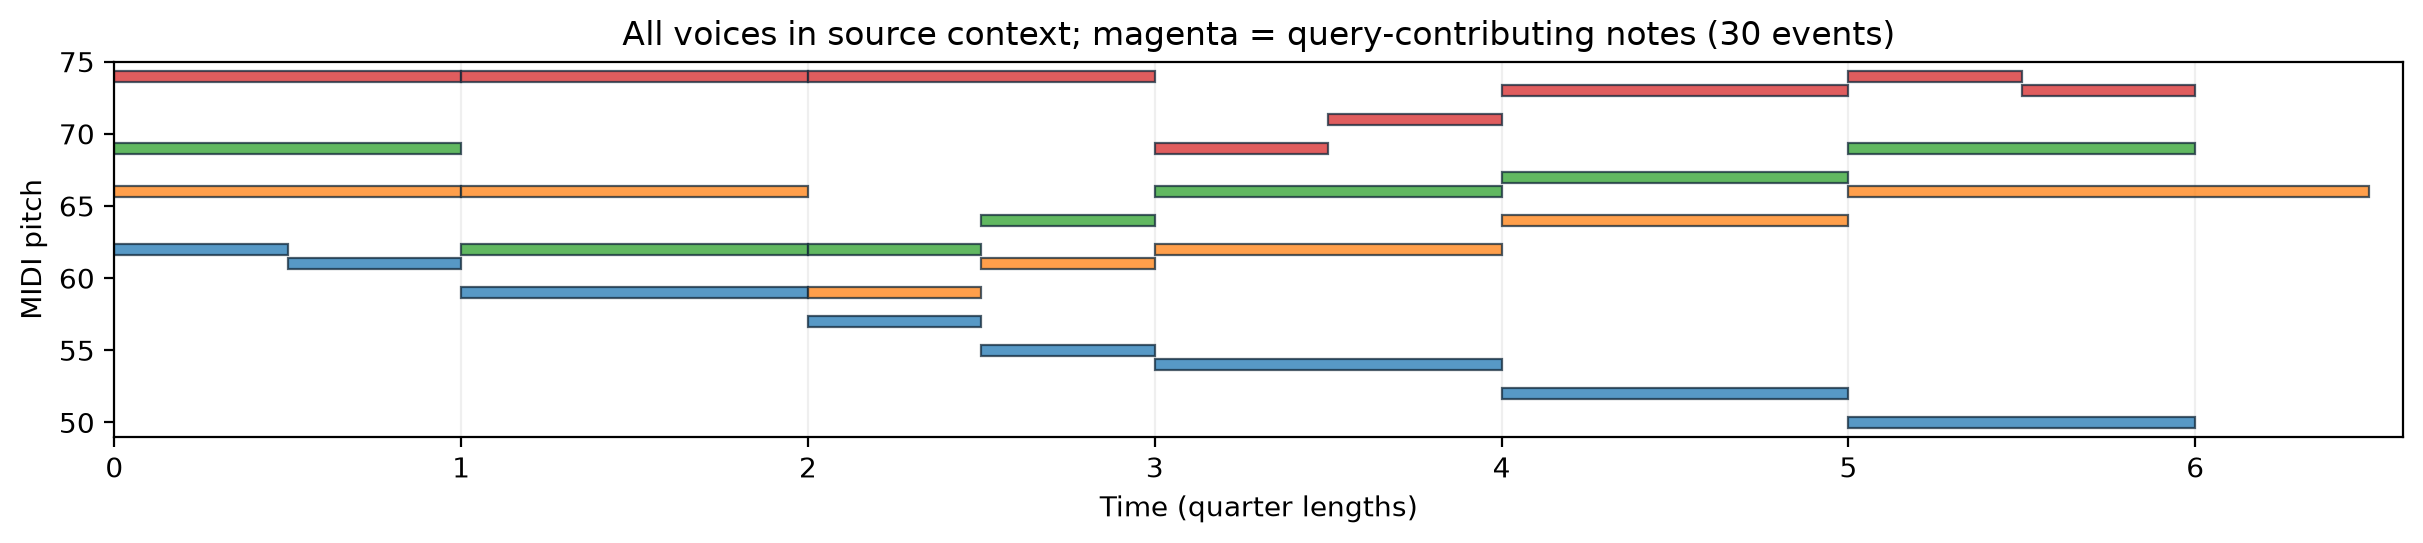

In [11]:
window = None
matched_notes = pd.DataFrame()
matched_xml_ids = []
if trace is None:
    print("No search window to interpret; run the MIDI search in section 7.")
else:
    window = trace["window"]
    window_notes = trace["window_notes"]
    matched_notes = trace["matched_notes"]
    matched_xml_ids = extract_selected_xml_ids(matched_notes) if not matched_notes.empty else []
    window.highlight_windows[0].update(
        name=f"Search rank {MATCH_RANK}, score {trace['score']:.2f}",
        color=WINDOW_COLOR, line_color=WINDOW_COLOR,
    )
    print(f"Raw window: rows {window.row_start}:{window.row_end}, columns {window.col_start}:{window.col_end}.")
    print(f"Source notes in rectangle: {len(window_notes)}; query contributors: {len(matched_notes)}.")
    window.plot(backend=PLOTTING_BACKEND, plot_width=1100, plot_height=340)
    if not matched_notes.empty:
        display(matched_notes[["xml_id", "Voice", "MIDI", "Source Global Onset", "Global Onset", "Duration"]])
        time_start = window.col_start * binary.meta["resolution"]
        time_stop = window.col_end * binary.meta["resolution"]
        context_notes = df_pitch_grid[
            (df_pitch_grid["Global Onset"] < time_stop + 2)
            & (df_pitch_grid["Global Onset"] + df_pitch_grid["Duration"] > max(0, time_start - 2))
        ]
        fig = plot_note_comparison(
            {"All voices in source context; magenta = query-contributing notes": context_notes},
            highlighted_ids=matched_xml_ids,
        )
        display(fig)
        plt.close(fig)


## 8. Read the matched notes in their original score context

The same xml:ids now highlight the original MEI. We render complete pages
containing the match, retaining surrounding notes, all staves and voices,
rests, clefs, key/time signatures and barlines. Only the contributing notes
change color. Nothing is removed or turned into invisible spacing.

This completes the chain: **selected fragment → query kernel → scored placement
→ binary window → contributing source rows → highlighted original notation**.
It explains a search result using the source score; no notation is inferred
from binary cells.

The main search walkthrough ends here. Sections 9–10 are an optional extension:
edit the toy grid to create a new query and see how its best score changes.


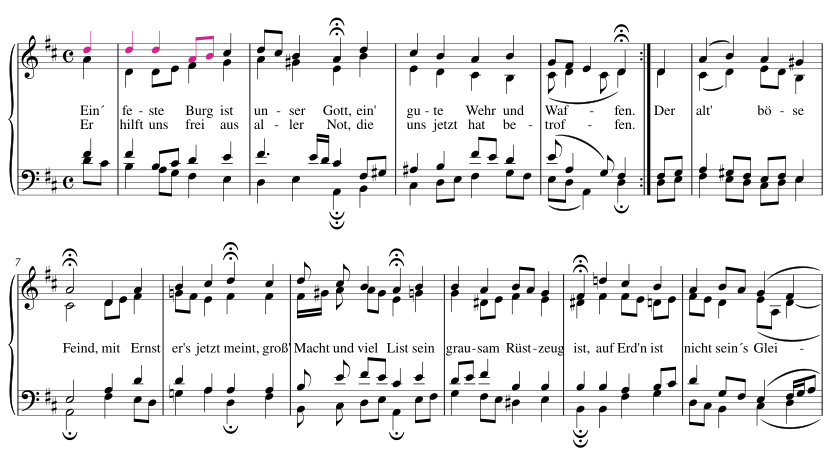

5 contributing notes highlighted on 1 complete source page(s).


In [12]:
RUN_SOURCE_NOTATION = True

if not RUN_SOURCE_NOTATION or mei_path is None or not matched_xml_ids:
    print("Source notation skipped: disabled or no contributing source IDs.")
else:
    source_mei = mei_path.read_text(encoding="utf-8")
    with vrv_quiet():
        vrv_set_options(
            pageWidth=2400, pageHeight=1600, scale=35, breaks="auto",
            adjustPageHeight=True, header="auto", removeIds=False, xmlIdSeed=0,
        )
        context_svgs = vrv_render_source_context(
            matched_notes, mei_xml=source_mei, highlight_color=WINDOW_COLOR,
            selected_pages_only=True, display=True,
        )
    print(f"{len(matched_xml_ids)} contributing notes highlighted on {len(context_svgs)} complete source page(s).")


## 9. Optional: edit the grid to create new musical material

Section 7 copied an existing fragment as a query. Here the question is:
**what happens if we change the pattern itself?**

Return to the toy grid, copy it, then shorten C4, remove the final G4 and add A4.
Decode the edited cells into a new note table, compare the piano rolls, and
generate a new symbolic score. Section 10 uses this edited grid as a query
against the original toy source, so the new pitch has a measurable effect on
the best match.

This is a separate editing experiment. The original MEI and its note identities
stay intact. Edited cells do not carry the old provenance: invented notes have
no original xml:id. Decode the edited array explicitly because a bundle's cached
`reconstructed_df` does not change after array edits.


Removed 4 cells; added 2 cells.


,MIDI,Global Onset,Duration
0,60,0.00,1.50
1,62,0.00,1.00
2,69,1.00,0.50
3,67,1.25,1.75
4,72,1.50,0.50
5,64,2.00,1.00


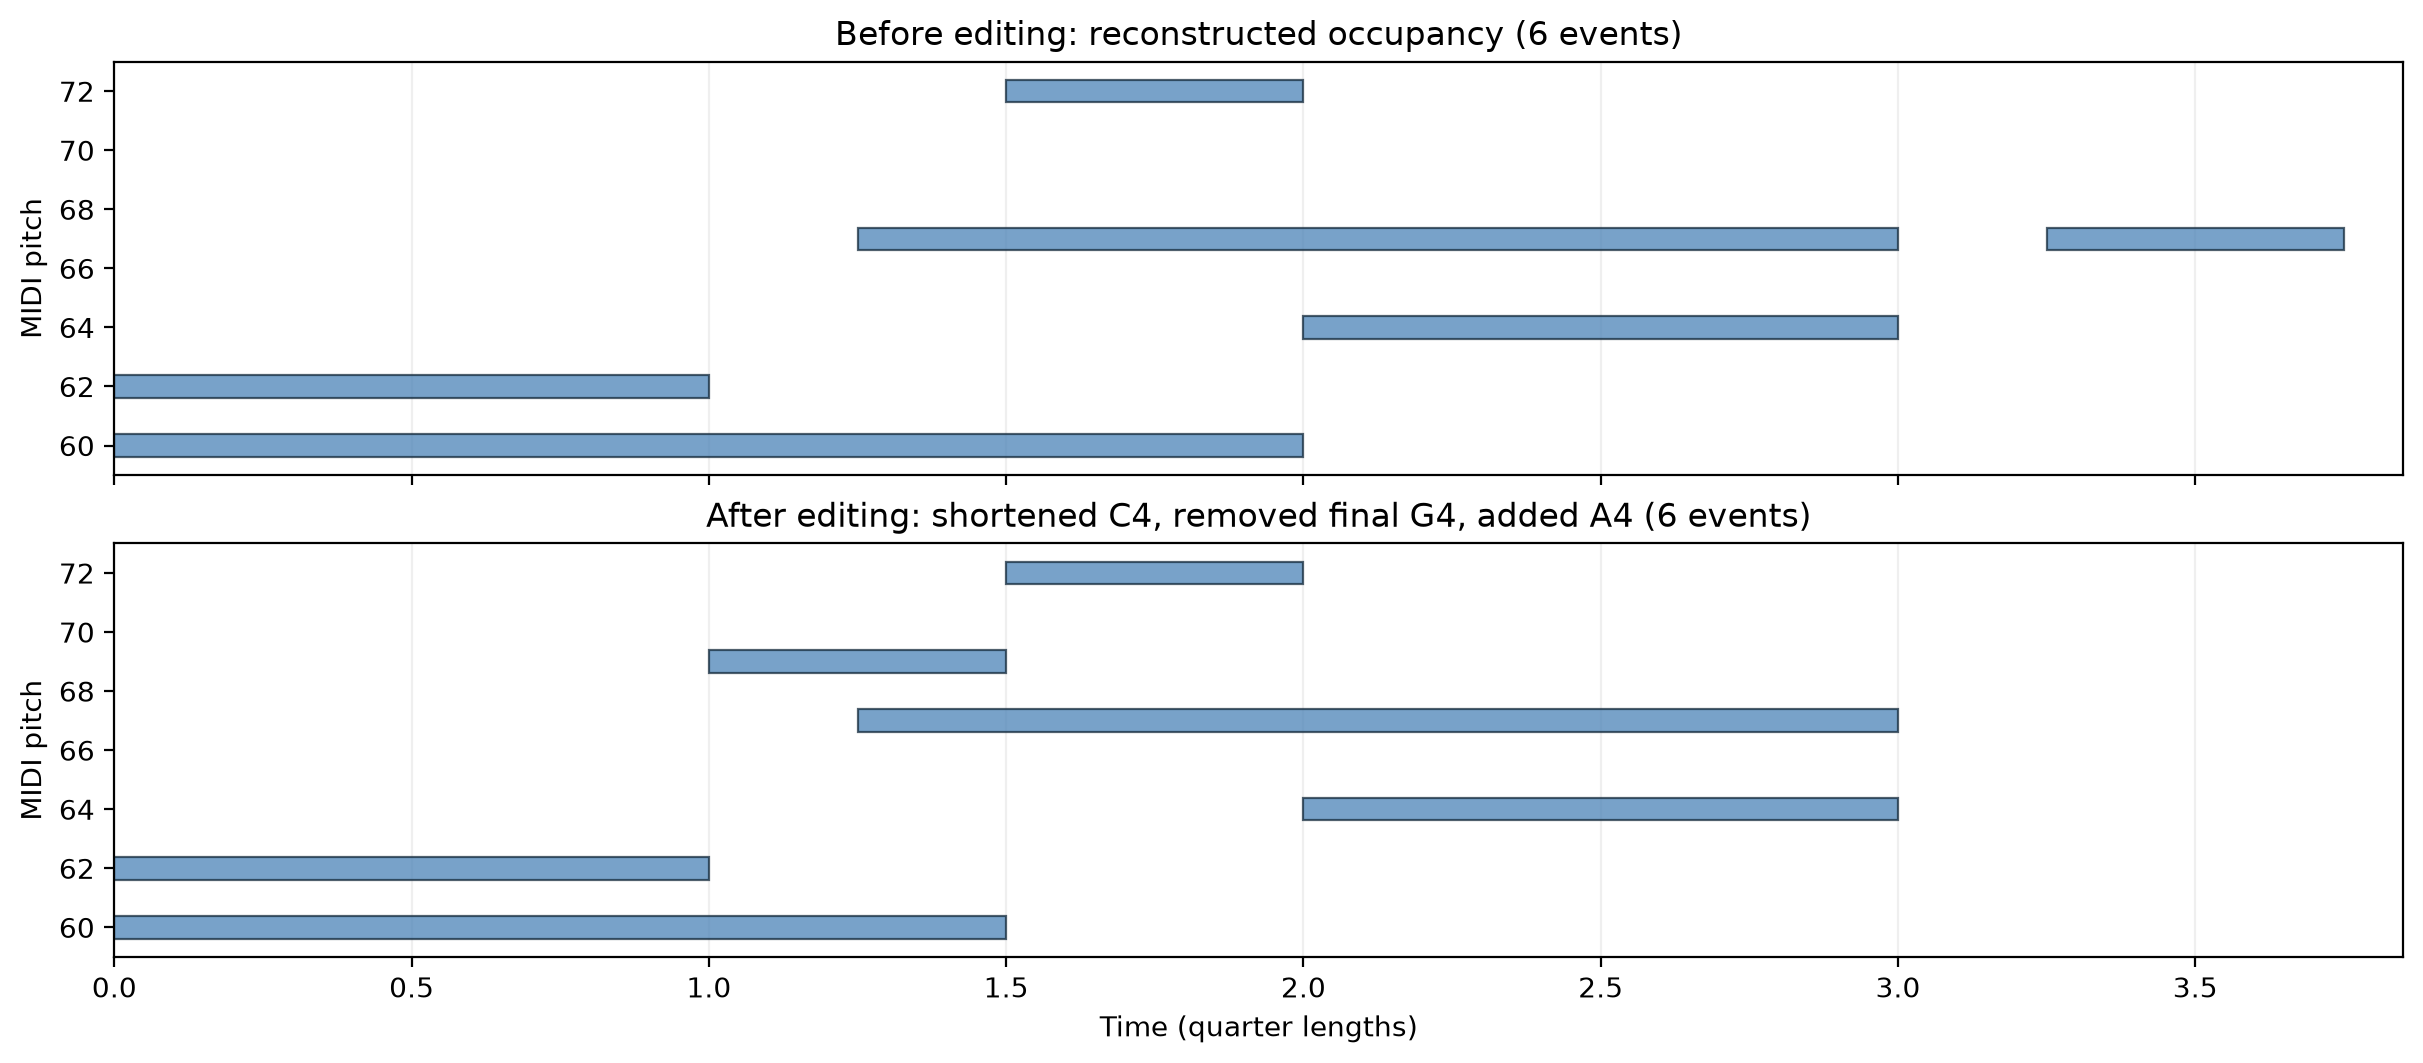

In [13]:
edited_matrix = toy.matrix.copy()
edited_meta = copy.deepcopy(toy.meta)
edited_meta.pop("provenance", None)

row_c4 = toy.meta["row_axis_values"].index(60)
row_g4 = toy.meta["row_axis_values"].index(67)
row_a4 = toy.meta["row_axis_values"].index(69)
edited_matrix[row_c4, 6:8] = 0   # shorten held C4 from 2.0 to 1.5 QL
edited_matrix[row_g4, 13:15] = 0  # remove G4 at 3.25–3.75 QL
edited_matrix[row_a4, 4:6] = 1   # add A4 at 1.0–1.5 QL

edited_df = binary_matrix_to_df_from_meta(edited_matrix, edited_meta)
removed_cells = int(np.count_nonzero((toy.matrix == 1) & (edited_matrix == 0)))
added_cells = int(np.count_nonzero((toy.matrix == 0) & (edited_matrix == 1)))
print(f"Removed {removed_cells} cells; added {added_cells} cells.")
display(edited_df)
assert "xml_id" not in edited_df
assert "provenance" not in edited_meta
assert toy.matrix[row_g4, 13:15].all()  # the source grid is unchanged

fig = plot_note_comparison({
    "Before editing: reconstructed occupancy": toy.reconstructed_df,
    "After editing: shortened C4, removed final G4, added A4": edited_df,
})
display(fig)
plt.close(fig)


### Generate fresh notation from the edited events

`df_to_music21` assigns voices and groups simultaneous notes into chords.
MusicXML and Verovio produce a new score with new identities. This rendering
shows the edited pitches and timing; original spelling, articulation, voice
allocation and notation choices are not recoverable from the binary matrix.

The variables `edited_musicxml`, `edited_mei` and `edited_svgs` remain available
for export. The cell does not overwrite the source score.


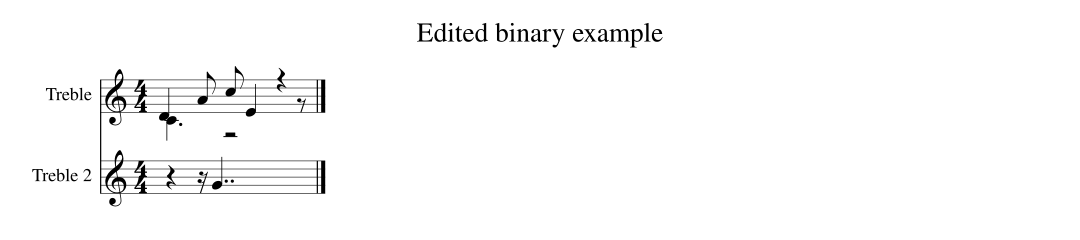

New notation: 1 SVG page(s).


In [14]:
edited_score = df_to_music21(
    edited_df, time_signature="4/4", piece_title="Edited binary example",
    clef_config="G", voices_per_stave=2,
)
edited_musicxml = music21_to_musicxml_string(edited_score)
with vrv_quiet():
    edited_mei, edited_svgs = render_with_verovio_from_musicxml(edited_musicxml, scale=45)
print(f"New notation: {len(edited_svgs)} SVG page(s).")

assert edited_svgs and "<note" in edited_mei, "Edited events must produce actual notation."


## 10. Optional: search with the edited query

Crop the edited grid to its active bounding box, keeping internal rests and
pitch spacing. This is the same extraction idea as section 7, now applied to
the material edited in section 9.

Search it against the **original toy host**. At the original position, the added
A4 cells are missing from the host; the trace marks them with red crosses.
The unchanged parts can still overlap. Shortening or removing notes does not
necessarily lower a containment score, because extra host notes are ignored.

The variables `edited_kernel` and `kernel_context` can also be used in the
[pattern-search notebook](binary_pattern_search.ipynb), with compatible
resolution and pitch-row order. The
[convolution explainer](binary_convolution_explained.ipynb) adds scale and pitch
augmentation experiments.


Kernel: (13, 12); active cells: 25


{'resolution': 0.25,
 'row_order': 'high_to_low',
 'y_mode': 'minmax',
 'source_row_offset': 0,
 'source_col_offset': 0,
 'pitch_rows': [72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60]}

,0,1,2,3,4,5,6,7,8,9,10,11
72,0,0,0,0,0,0,1,1,0,0,0,0
71,0,0,0,0,0,0,0,0,0,0,0,0
70,0,0,0,0,0,0,0,0,0,0,0,0
69,0,0,0,0,1,1,0,0,0,0,0,0
68,0,0,0,0,0,0,0,0,0,0,0,0
67,0,0,0,0,0,1,1,1,1,1,1,1
66,0,0,0,0,0,0,0,0,0,0,0,0
65,0,0,0,0,0,0,0,0,0,0,0,0
64,0,0,0,0,0,0,0,0,1,1,1,1
63,0,0,0,0,0,0,0,0,0,0,0,0


,score,row,col,grid_onset_QL,source_onset_QL,anchor_MIDI
0,0.92,0,0,0.00,0.00,72
1,0.76,0,1,0.25,0.25,72
2,0.64,0,2,0.50,0.50,72
3,0.52,0,3,0.75,0.75,72


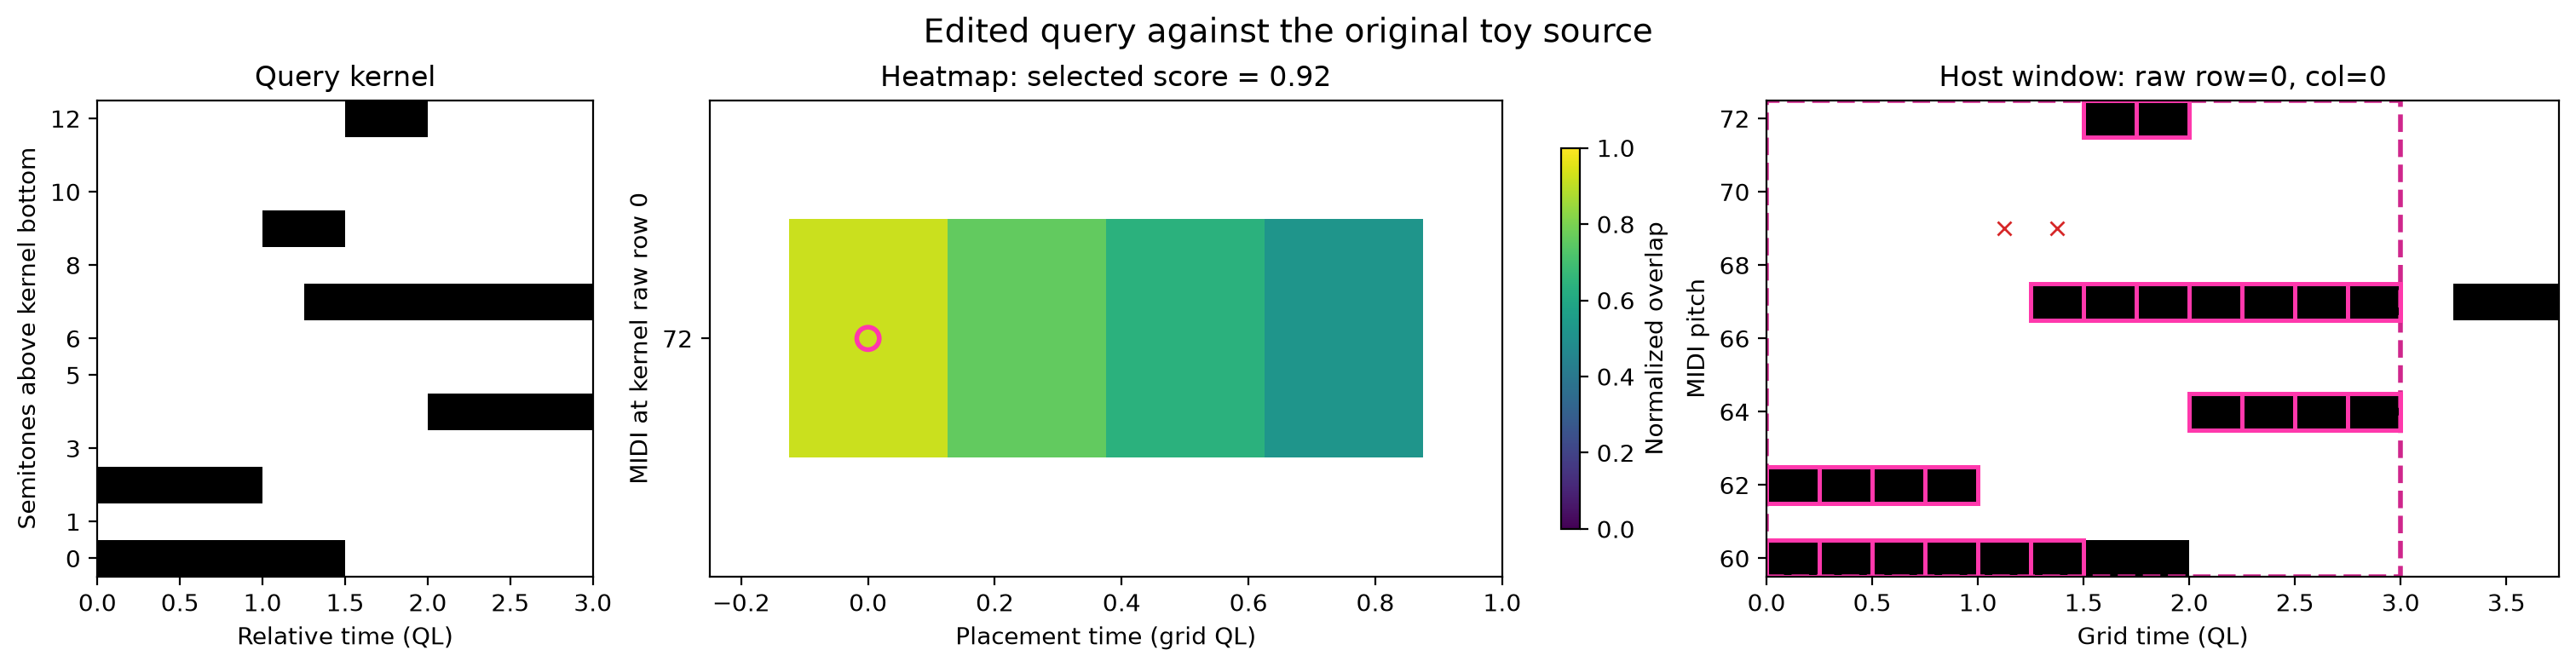

Best score: 0.92; missing query cells: 2.


In [15]:
active_rows, active_cols = np.where(edited_matrix > 0)
r0, r1 = int(active_rows.min()), int(active_rows.max()) + 1
c0, c1 = int(active_cols.min()), int(active_cols.max()) + 1
edited_kernel = edited_matrix[r0:r1, c0:c1].copy()
kernel_context = {
    "resolution": edited_meta["resolution"],
    "row_order": edited_meta["row_order"],
    "y_mode": edited_meta["y_mode"],
    "source_row_offset": r0,
    "source_col_offset": c0,
    "pitch_rows": edited_meta["row_axis_values"][r0:r1],
}
print(f"Kernel: {edited_kernel.shape}; active cells: {int(edited_kernel.sum())}")
display(kernel_context)
display(pd.DataFrame(edited_kernel, index=kernel_context["pitch_rows"]))

edited_search = find_binary_matches(toy, edited_kernel)
display(edited_search["matches"])
fig = plot_binary_search_trace(
    toy, edited_kernel, edited_search,
    title="Edited query against the original toy source",
)
display(fig)
plt.close(fig)
edited_hit = edited_search["matches"].iloc[0]
edited_trace = binary_match_sources(toy, edited_kernel, edited_hit["row"], edited_hit["col"])
print(f"Best score: {edited_hit['score']:.2f}; missing query cells: {len(edited_trace['missing_cells'])}.")
assert edited_hit["score"] < 1.0  # the original source has no A4


The experiments leave three distinct objects to inspect:

- **Original source + provenance:** original events and their notation identities.
- **Binary grid + axis metadata:** occupied pitch/time cells and their coordinate system.
- **Reconstructed or edited events:** contiguous runs with generated timing and pitch,
  suitable for a new piano roll, notation rendering or search query.

Try a coarser source resolution, then chroma, then reverse the row order. Cell
equality, event equality and source identity answer different questions; the
audit tables keep those questions visible.
